# Multivariate Normal Distribution

`MultivariateNormal(mean, cov)` generalizes the normal distribution to several dimensions at once. Each draw is a *vector* of correlated normal values, described by a mean vector and a covariance matrix.

In [1]:
from symbulate import *

## Draw a value

Each draw is a vector, one entry per dimension.

In [2]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).draw()

(-0.93316223562003, -0.42226222655959705)

## Simulate

Every simulated value is a 2-dimensional vector.

In [3]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).sim(1000)

0,"(0.23037245787371047, 0.7653413934472271)"
1,"(1.0092942462085113, 0.14698751213662298)"
2,"(-1.4177072029138107, -1.6519599582742268)"
3,"(-0.8576619230032912, -0.37364158626053845)"
4,"(0.7520946263205108, -0.2722251929770504)"
5,"(1.3379368198897763, 1.397218013456241)"
6,"(-0.41448574754665746, 0.4133181217208154)"
7,"(1.6266093223982954, 1.7878625003477402)"
8,"(-0.3447109780526416, -1.3926394810788134)"
...,...
999,"(0.9196633660545317, 0.18152954841996288)"


## Mean, variance, and standard deviation

For a vector-valued distribution these each return one value per component.

In [4]:
X = MultivariateNormal(mean=[1, 2, 3], cov=[[4, 1, 0.5], [1, 2, -0.3], [0.5, -0.3, 1]])
X.mean(), X.var(), X.sd()

((1, 2, 3), (4.0, 2.0, 1.0), (2.0, 1.4142135623730951, 1.0))

## Covariance matrix

`cov()` returns the full covariance matrix.

In [5]:
X.cov()

array([[ 4. ,  1. ,  0.5],
       [ 1. ,  2. , -0.3],
       [ 0.5, -0.3,  1. ]])

## Correlation matrix

`corr()` rescales the covariance matrix into correlations between -1 and 1.

In [6]:
X.corr()

array([[ 1.        ,  0.35355339,  0.25      ],
       [ 0.35355339,  1.        , -0.21213203],
       [ 0.25      , -0.21213203,  1.        ]])

## Evaluate the pdf at a point

In [7]:
MultivariateNormal(mean=[0, 0], cov=[[1, 0.8], [0.8, 1]]).pdf([0, 0])

np.float64(0.26525823848649227)

## Relationship: each component is a univariate Normal

Every component of a multivariate normal is itself an ordinary `Normal`, with mean `mean_i` and standard deviation `sqrt(cov_ii)`.

Currently Showing: Density Plot
Alternative Plots: Histogram (Default), Rug Plot (type = "rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


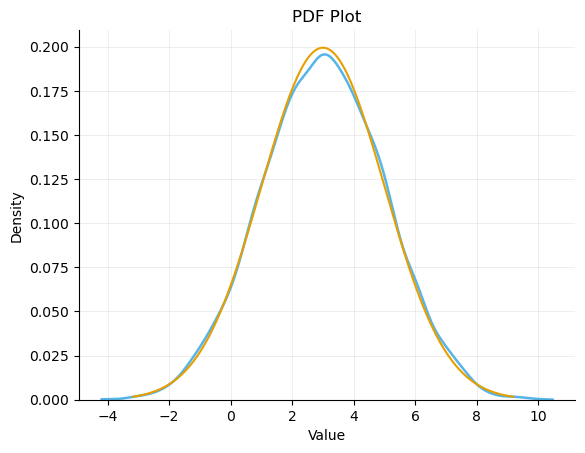

In [8]:
X, Y = RV(MultivariateNormal(mean=[3, 7], cov=[[4, 0], [0, 9]]))
X.sim(10000).plot(type="density")
Normal(mean=3, sd=2).plot()

## Relationship: any linear combination of the components is Normal

A weighted sum of the components is again a (one-dimensional) normal, with a variance that accounts for the correlation between them. For `X, Y` from `MultivariateNormal([0, 0], [[1, 0.5], [0.5, 1]])`, the sum `X + Y` has mean 0 and variance `1 + 1 + 2*0.5 = 3`, or just `Normal(0, sd=sqrt(3))`.

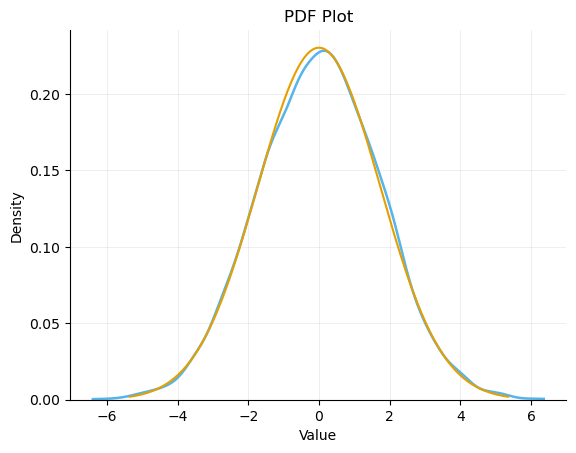

In [9]:
X, Y = RV(MultivariateNormal(mean=[0, 0], cov=[[1, 0.5], [0.5, 1]]))
(X + Y).sim(10000).plot(type="density")
Normal(mean=0, sd=3 ** 0.5).plot()